## **COE 292 - (Preliminary Results)**




### Course: COE 292 - Introduction to AI
### Team ID: 3
### Team Members: [Yasmieen Alshehri, Sarah Alshammari, Alanoud Althobaiti]
### Dataset Selected: [Stress Level Dataset]


# Dataset Exploration

In [139]:
import pandas as pd
import numpy as np

df = pd.read_csv('StressLevelDataset.csv', delimiter = ',')
display(df.head())
display(df.info())
print('Total samples:', len(df))
print('Features:', df.shape[1])
print('Classes:', df['stress_level'].unique())
print('Distribution:', df['stress_level'].value_counts())

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

None

Total samples: 1100
Features: 21
Classes: [1 2 0]
Distribution: stress_level
0    373
2    369
1    358
Name: count, dtype: int64


# Data Visualization

In [141]:
# output is stress_level
# conduct PCA
pca_input_col = df.columns.drop('stress_level')
print(pca_input_col)

from sklearn.decomposition import PCA
pca = PCA(n_components=2) # get pca model

principalComponents = pca.fit_transform(df[pca_input_col]) # get 2 comp

df['pca1'] = principalComponents[:,0]
df['pca2'] = principalComponents[:,1]

display(df)

# how much variation is captured by each pca
for ind,var in enumerate(pca.explained_variance_ratio_):
  print(f'The Variance captured by pca {ind+1} is: {var*100: 0.2f}%')

# for the pca1 what are the cofficients for each pca and which has the highest

pca_1_cofficients = np.round(pca.components_[0],4)

zipList = list(zip(pca_input_col,pca_1_cofficients))
ndf = pd.DataFrame(zipList, columns = ['factor', 'coeff'])
display(ndf.sort_values(by = ['coeff'], ascending = False))

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying'],
      dtype='object')


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level,pca1,pca2
0,14,20,0,11,2,1,2,4,2,3,...,2,3,3,2,3,3,2,1,-1.180389,-1.439001
1,15,8,1,15,5,3,1,4,3,1,...,4,1,5,1,4,5,5,2,11.288236,3.991630
2,12,18,1,14,2,1,2,2,2,2,...,3,3,2,2,3,2,2,1,0.889085,-1.308880
3,16,12,1,15,4,3,1,3,4,2,...,4,1,4,1,4,4,5,2,8.659229,0.928455
4,16,28,0,7,2,3,5,1,3,2,...,3,1,2,1,5,0,5,1,-7.989507,-5.173216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,11,17,0,14,3,1,3,2,2,2,...,2,2,3,3,2,3,3,1,1.245171,-0.361907
1096,9,12,0,8,0,3,0,0,0,1,...,1,1,1,1,3,4,3,2,0.430334,7.656363
1097,4,26,0,3,1,2,5,2,2,3,...,1,4,1,3,1,2,1,0,-15.233414,2.384644
1098,21,0,1,19,5,3,1,4,3,1,...,5,1,4,1,4,4,4,2,21.086924,5.730470


The Variance captured by pca 1 is:  76.05%
The Variance captured by pca 2 is:  10.27%


,factor,coeff
3,depression,0.5485
0,anxiety_level,0.4081
15,future_career_concerns,0.0984
19,bullying,0.0925
18,extracurricular_activities,0.0826
4,headache,0.0816
17,peer_pressure,0.0809
13,study_load,0.0697
8,noise_level,0.0696
7,breathing_problem,0.0669


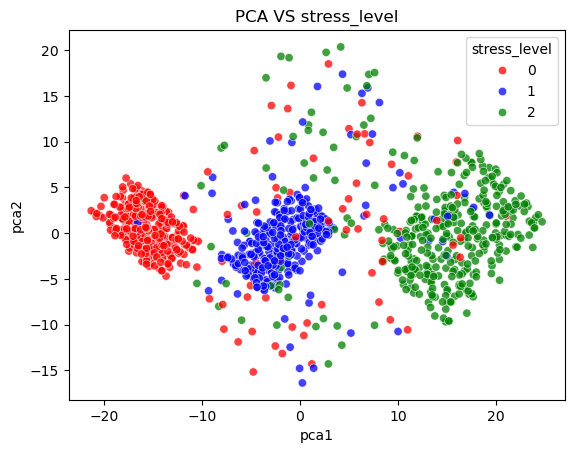

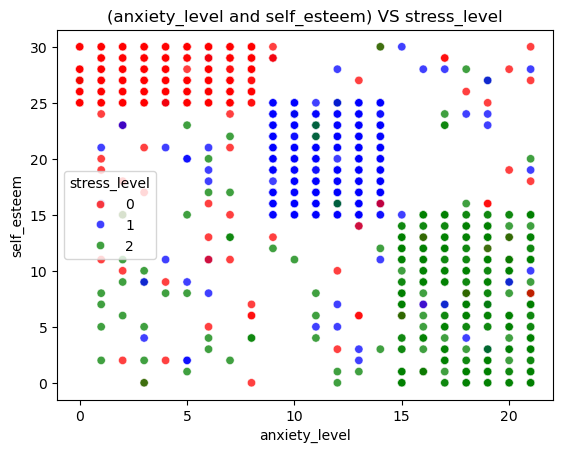

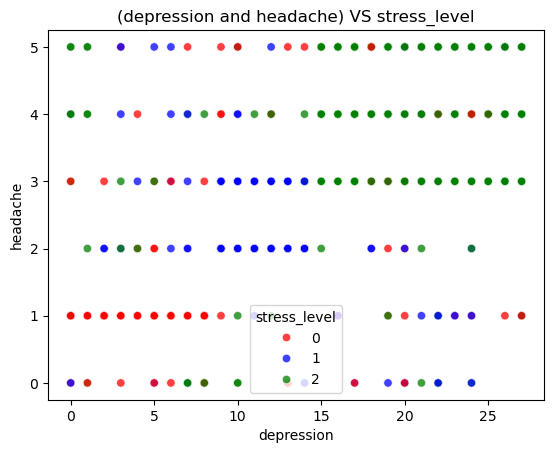

In [142]:
# construct a scatter plot using the first two pca of the data
# differentiate the points using 'stress_level'

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.scatterplot(x = 'pca1', y = 'pca2', hue = 'stress_level', palette = ['r', 'b', 'g'], alpha = 0.75, data = df)
plt.title('PCA VS stress_level')
plt.show()

# 2nd scatter plot two features and 'stress_level'
plt.figure()
sns.scatterplot(x = 'anxiety_level', y = 'self_esteem', hue = 'stress_level', palette = ['r', 'b', 'g'], alpha = 0.75, data = df)
plt.title('(anxiety_level and self_esteem) VS stress_level')
plt.show()

plt.figure()
sns.scatterplot(x = 'depression', y = 'headache', hue = 'stress_level', palette = ['r', 'b', 'g'], alpha = 0.75, data = df)
plt.title('(depression and headache) VS stress_level')
plt.show()

# Dataset Exploration and Preparation 

In [144]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('stress_level', axis=1))
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


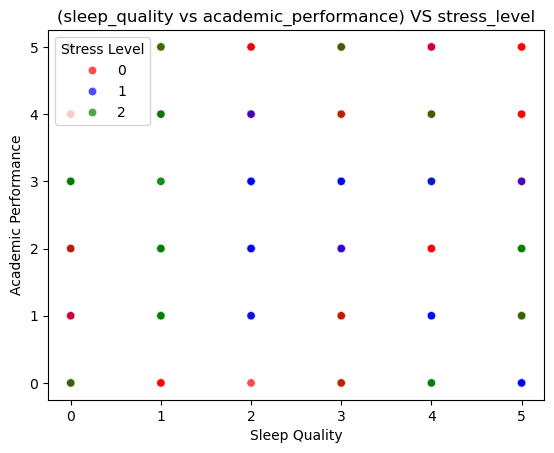

In [145]:
plt.figure()
sns.scatterplot(
    x='sleep_quality',
    y='academic_performance',
    hue='stress_level',
    palette=['red', 'blue', 'green'],
    alpha=0.7,
    data=df
)
plt.xlabel('Sleep Quality')
plt.ylabel('Academic Performance')
plt.title('(sleep_quality vs academic_performance) VS stress_level')
plt.legend(title='Stress Level')
plt.show()


#  Classification Algorithm 1 – K-Nearest Neighbors 

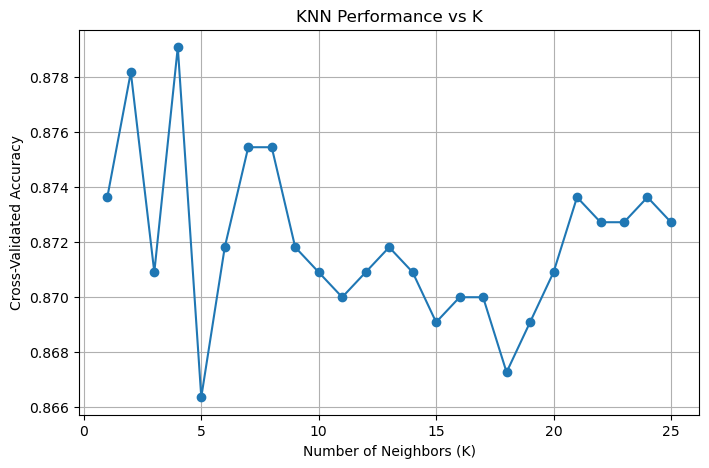

Accuracy: 0.8918181818181818
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       373
           1       0.84      0.92      0.88       358
           2       0.90      0.88      0.89       369

    accuracy                           0.89      1100
   macro avg       0.89      0.89      0.89      1100
weighted avg       0.89      0.89      0.89      1100

Specificity per class: [0.9724896836313618, 0.9164420485175202, 0.9493844049247606]


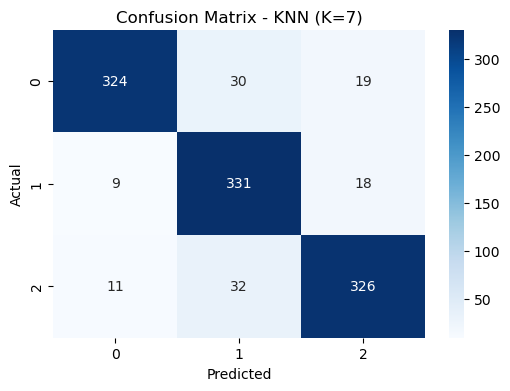


=== K-NN (K=7) 5-fold CV metrics (per fold) ===


,Fold,Accuracy,Precision,Recall,F1,Specificity
0,1,0.877273,0.884271,0.877628,0.878083,0.938912
1,2,0.900000,0.903380,0.900150,0.900570,0.950173
2,3,0.859091,0.870107,0.860391,0.858720,0.929887
3,4,0.854545,0.859226,0.855675,0.854415,0.927597
4,5,0.890909,0.892496,0.891971,0.890439,0.945586



Mean ± Std:


Fold              3.0 ± 1.5811
Accuracy       0.8764 ± 0.0197
Precision      0.8819 ± 0.0176
Recall         0.8772 ± 0.0193
F1             0.8764 ± 0.0199
Specificity    0.9384 ± 0.0097
dtype: object


=== K-NN (K=7) 5-fold CV metrics (per fold) ===


,Fold,Accuracy,Precision,Recall,F1,Specificity
0,1,0.877273,0.884271,0.877628,0.878083,0.938912
1,2,0.900000,0.903380,0.900150,0.900570,0.950173
2,3,0.859091,0.870107,0.860391,0.858720,0.929887
3,4,0.854545,0.859226,0.855675,0.854415,0.927597
4,5,0.890909,0.892496,0.891971,0.890439,0.945586



Mean ± Std:


Fold              3.0 ± 1.5811
Accuracy       0.8764 ± 0.0197
Precision      0.8819 ± 0.0176
Recall         0.8772 ± 0.0193
F1             0.8764 ± 0.0199
Specificity    0.9384 ± 0.0097
dtype: object

In [147]:
 
X = df.drop('stress_level', axis=1)
y = df['stress_level']

#   Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  KNN and Cross Validation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

k_values = range(1, 26)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=cv, scoring='accuracy')
    accuracies.append(scores.mean())

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Performance vs K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validated Accuracy')
plt.grid(True)
plt.show()

#  Final KNN Model with K=7
from sklearn.metrics import classification_report, confusion_matrix

knn_final = KNeighborsClassifier(n_neighbors=7)
knn_final.fit(X_scaled, y)

y_pred = knn_final.predict(X_scaled)
accuracy = knn_final.score(X_scaled, y)

print("Accuracy:", accuracy)
print(classification_report(y, y_pred))

#  Specificity calculation
cm = confusion_matrix(y, y_pred)
specificity = []

for i in range(3):
    TN = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    FP = cm[:,i].sum() - cm[i,i]
    specificity.append(TN / (TN + FP))

print("Specificity per class:", specificity)

#  Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])
plt.title("Confusion Matrix - KNN (K=7)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

def macro_specificity_from_cm(cm):
    specs = []
    n_classes = cm.shape[0]
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specs.append(spec)
    return np.mean(specs)
 
def cv_per_fold(pipe, X, y, cv, model_name="Model"):
    rows = []
    fold_id = 1

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_val, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        cm = confusion_matrix(y_val, y_pred)
        spec = macro_specificity_from_cm(cm)

        rows.append({
            "Fold": fold_id,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "Specificity": spec
        })
        fold_id += 1

    df = pd.DataFrame(rows)
    print(f"\n=== {model_name} 5-fold CV metrics (per fold) ===")
    display(df)
    print("\nMean ± Std:")
    display(df.mean().round(4).astype(str) + " ± " + df.std().round(4).astype(str))
    return df


best_k = 7


best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])


knn_cv_folds = cv_per_fold(best_knn, X, y, cv, model_name=f"K-NN (K={best_k})")


from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
 
def macro_specificity_from_cm(cm):
    specs = []
    n_classes = cm.shape[0]
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specs.append(spec)
    return np.mean(specs)
 
def cv_per_fold(pipe, X, y, cv, model_name="Model"):
    rows = []
    fold_id = 1

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_val, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        cm = confusion_matrix(y_val, y_pred)
        spec = macro_specificity_from_cm(cm)

        rows.append({
            "Fold": fold_id,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "Specificity": spec
        })
        fold_id += 1

    df = pd.DataFrame(rows)
    print(f"\n=== {model_name} 5-fold CV metrics (per fold) ===")
    display(df)
    print("\nMean ± Std:")
    display(df.mean().round(4).astype(str) + " ± " + df.std().round(4).astype(str))
    return df
 

knn_cv_folds = cv_per_fold(best_knn, X, y, cv, model_name=f"K-NN (K={best_k})")



# Classification Algorithm 2 – Support Vector Machine


=== 5-fold CV – SVM Kernels (stress.csv) ===
 Kernel  Acc_mean  Acc_std  F1_macro_mean  F1_macro_std
 linear  0.882727 0.015851       0.883037      0.015814
    rbf  0.875455 0.019625       0.876439      0.019318
   poly  0.873636 0.008814       0.873691      0.009265
sigmoid  0.890000 0.013299       0.890541      0.013021

Best kernel by CV macro F1: sigmoid
Kernel            sigmoid
Acc_mean             0.89
Acc_std          0.013299
F1_macro_mean    0.890541
F1_macro_std     0.013021
Name: 3, dtype: object

Confusion matrix:
 [[79  2 12]
 [ 8 79  3]
 [ 9  2 81]]

Classification report:

              precision    recall  f1-score   support

           0     0.8229    0.8495    0.8360        93
           1     0.9518    0.8778    0.9133        90
           2     0.8438    0.8804    0.8617        92

    accuracy                         0.8691       275
   macro avg     0.8728    0.8692    0.8703       275
weighted avg     0.8721    0.8691    0.8699       275


Per-class Sensitivit

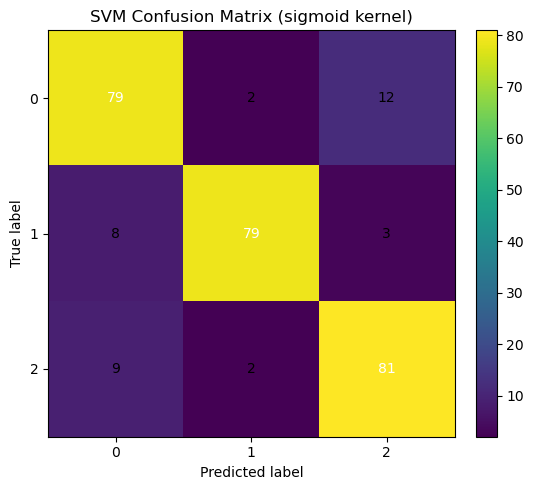


Number of support vectors: 181


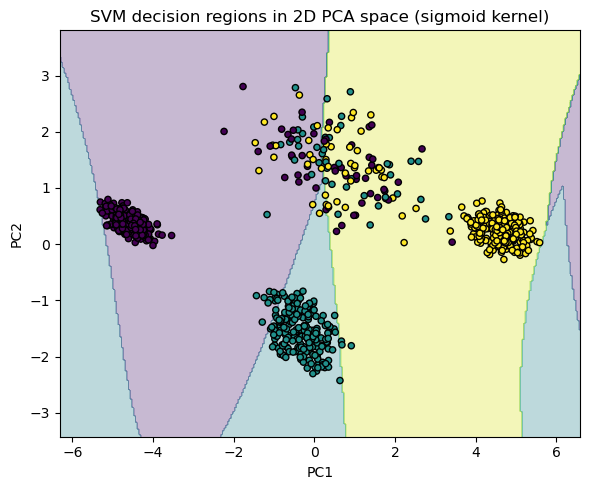

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.decomposition import PCA


# Load data & split

df = pd.read_csv("StressLevelDataset.csv")
X = df.drop("stress_level", axis=1).values
y = df["stress_level"].values

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


# Scaling method (StandardScaler)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#  5-fold CV: compare kernels

kernels = ["linear", "rbf", "poly", "sigmoid"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []

for ker in kernels:
    svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=ker, random_state=42))
    ])

    acc_scores = cross_val_score(svm_clf, X, y, cv=cv, scoring="accuracy")
    f1_scores  = cross_val_score(svm_clf, X, y, cv=cv, scoring="f1_macro")

    cv_rows.append({
        "Kernel": ker,
        "Acc_mean": acc_scores.mean(),
        "Acc_std": acc_scores.std(),
        "F1_macro_mean": f1_scores.mean(),
        "F1_macro_std": f1_scores.std()
    })

cv_df = pd.DataFrame(cv_rows)
print("\n=== 5-fold CV – SVM Kernels (stress.csv) ===")
print(cv_df.to_string(index=False))

# Choose best kernel by macro F1
best_row = cv_df.sort_values("F1_macro_mean", ascending=False).iloc[0]
best_kernel = best_row["Kernel"]
print(f"\nBest kernel by CV macro F1: {best_kernel}")
print(best_row)


# Train final SVM with best kernel

final_svm = SVC(kernel=best_kernel, random_state=42)
final_svm.fit(X_train_scaled, y_train)
y_pred = final_svm.predict(X_test_scaled)
# Performance metrics on test set

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:\n", cm)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

# Per-class sensitivity & specificity
def per_class_sensitivity_specificity(y_true, y_pred):
    labels = np.unique(y_true)
    rows = []
    for lab in labels:
        tp = np.sum((y_true == lab) & (y_pred == lab))
        tn = np.sum((y_true != lab) & (y_pred != lab))
        fp = np.sum((y_true != lab) & (y_pred == lab))
        fn = np.sum((y_true == lab) & (y_pred != lab))

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0  
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0   

        rows.append({
            "Class": lab,
            "Sensitivity": sens,
            "Specificity": spec
        })

    return pd.DataFrame(rows)

sens_spec_df = per_class_sensitivity_specificity(y_test, y_pred)
print("\nPer-class Sensitivity / Specificity:")
print(sens_spec_df.to_string(index=False))

macro_specificity = sens_spec_df["Specificity"].mean()

print("\n=== Overall test metrics (final SVM) ===")
print(f"Accuracy          : {acc:.4f}")
print(f"Macro Precision   : {prec_macro:.4f}")
print(f"Macro Recall      : {recall_macro:.4f}  (Sensitivity)")
print(f"Macro Specificity : {macro_specificity:.4f}")
print(f"Macro F1-score    : {f1_macro:.4f}")
 
# Plot confusion matrix (heatmap) 
plt.figure(figsize=(6,5))
im = plt.imshow(cm, interpolation="nearest")
plt.title(f"SVM Confusion Matrix ({best_kernel} kernel)")
plt.colorbar(im, fraction=0.046, pad=0.04)
tick_marks = np.arange(len(np.unique(y)))
plt.xticks(tick_marks, np.unique(y))
plt.yticks(tick_marks, np.unique(y))
plt.xlabel("Predicted label")
plt.ylabel("True label")

# annotate counts
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()

# Support vectors
support_vectors = final_svm.support_vectors_
print(f"\nNumber of support vectors: {support_vectors.shape[0]}")

# Decision boundary (2D PCA)
#    -> For explanation of support vectors / boundary

# Project scaled train data to 2D with PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)

svm_2d = SVC(kernel=best_kernel, random_state=42)
svm_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    edgecolors="k",
    s=20
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"SVM decision regions in 2D PCA space ({best_kernel} kernel)")
plt.tight_layout()
plt.show()


# Classification Algorithm 3 – Deep Learning (MLP)

,architecture,alpha,learning_rate,avg_accuracy
4,"(128, 64)",0.0001,0.001,0.886364
0,"(32,)",0.0001,0.001,0.885455
1,"(32,)",0.0005,0.001,0.884545
5,"(128, 64)",0.0005,0.001,0.884545
2,"(64, 32)",0.0001,0.001,0.878182
3,"(64, 32)",0.0005,0.001,0.878182



--- Fold 1 ---
[[67  4  3]
 [ 3 67  2]
 [ 7  3 64]]
Accuracy = 0.9000
Precision(macro) = 0.9010
Recall(macro) = 0.9003
Specificity(macro) = 0.9500
F1(macro) = 0.9001

--- Fold 2 ---
[[69  1  4]
 [ 5 63  4]
 [ 2  3 69]]
Accuracy = 0.9136
Precision(macro) = 0.9148
Recall(macro) = 0.9133
Specificity(macro) = 0.9567
F1(macro) = 0.9135

--- Fold 3 ---
[[60  4 11]
 [ 2 65  5]
 [ 5  6 62]]
Accuracy = 0.8500
Precision(macro) = 0.8524
Recall(macro) = 0.8507
Specificity(macro) = 0.9251
F1(macro) = 0.8502

--- Fold 4 ---
[[68  2  5]
 [ 4 62  5]
 [ 6  1 67]]
Accuracy = 0.8955
Precision(macro) = 0.8986
Recall(macro) = 0.8951
Specificity(macro) = 0.9475
F1(macro) = 0.8960

--- Fold 5 ---
[[63  5  7]
 [ 4 62  5]
 [ 4  3 67]]
Accuracy = 0.8727
Precision(macro) = 0.8737
Recall(macro) = 0.8729
Specificity(macro) = 0.9363
F1(macro) = 0.8728


,fold,accuracy,precision_macro,recall_macro,specificity_macro,f1_macro
0,1,0.900000,0.901024,0.900275,0.949988,0.900110
1,2,0.913636,0.914766,0.913288,0.956744,0.913461
2,3,0.850000,0.852354,0.850698,0.925104,0.850205
3,4,0.895455,0.898590,0.895104,0.947469,0.896024
4,5,0.872727,0.873713,0.872882,0.936315,0.872754



=== Mean ± Std (5-Fold CV) ===


,mean,std,mean ± std
accuracy,0.886364,0.025103,0.8864 ± 0.0251
precision_macro,0.888089,0.024864,0.8881 ± 0.0249
recall_macro,0.886449,0.024742,0.8864 ± 0.0247
specificity_macro,0.943124,0.012476,0.9431 ± 0.0125
f1_macro,0.886511,0.025045,0.8865 ± 0.0250


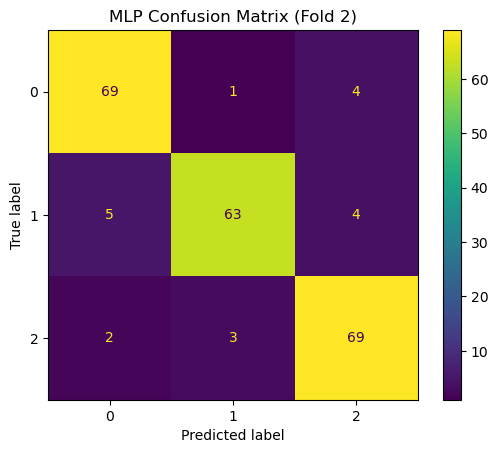


=== Final Average Metrics (5-Fold) ===
fold                 3.000000
accuracy             0.886364
precision_macro      0.888089
recall_macro         0.886449
specificity_macro    0.943124
f1_macro             0.886511
dtype: float64


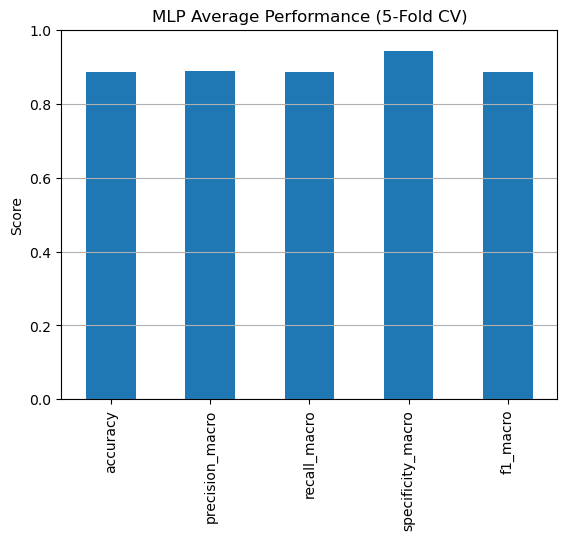

In [151]:
# =========================
#           MLP
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

# 0) Load Dataset

DATA_PATH = "StressLevelDataset.csv"   
TARGET_COL = "stress_level"           

df = pd.read_csv(DATA_PATH)

# extract X,y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]


# Helper function: Multiclass Specificity

def multiclass_specificity(cm):
    C = cm.shape[0]
    specs = []
    for i in range(C):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specs.append(spec)
    return np.array(specs), np.mean(specs)


# 1) Stratified 5-Fold CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 2) Hyperparameter Experiments

architectures = [(32,), (64, 32), (128, 64)]
alphas = [0.0001, 0.0005]
learning_rates = [0.001]

trial_rows = []

for arch in architectures:
    for a in alphas:
        for lr in learning_rates:

            fold_acc = []

            for train_idx, test_idx in skf.split(X, y):
                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                scaler = StandardScaler()
                X_train_sc = scaler.fit_transform(X_train)
                X_test_sc = scaler.transform(X_test)

                mlp_trial = MLPClassifier(
                    hidden_layer_sizes=arch,
                    activation="relu",
                    solver="adam",
                    alpha=a,
                    learning_rate_init=lr,
                    batch_size=32,
                    max_iter=300,
                    random_state=42
                )

                mlp_trial.fit(X_train_sc, y_train)
                y_pred = mlp_trial.predict(X_test_sc)
                fold_acc.append(accuracy_score(y_test, y_pred))

            trial_rows.append({
                "architecture": arch,
                "alpha": a,
                "learning_rate": lr,
                "avg_accuracy": np.mean(fold_acc)
            })

# Rankings
trials_df = pd.DataFrame(trial_rows).sort_values("avg_accuracy", ascending=False)
display(trials_df)

best_setting = trials_df.iloc[0]
BEST_ARCH = best_setting["architecture"]
BEST_ALPHA = best_setting["alpha"]
BEST_LR = best_setting["learning_rate"]



# 3) Train Final MLP using Best Hyperparameters

fold_results = []
fold = 1

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    mlp = MLPClassifier(
        hidden_layer_sizes=BEST_ARCH,
        activation="relu",
        solver="adam",
        alpha=BEST_ALPHA,
        learning_rate_init=BEST_LR,
        batch_size=32,
        max_iter=300,
        random_state=42
    )

    mlp.fit(X_train_sc, y_train)
    y_pred = mlp.predict(X_test_sc)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_macro  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro   = f1_score(y_test, y_pred, average="macro", zero_division=0)

    _, spec_macro = multiclass_specificity(cm)

    fold_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "specificity_macro": spec_macro,
        "f1_macro": f1_macro,
        "confusion_matrix": cm
    })

    print(f"\n--- Fold {fold} ---")
    print(cm)
    print(f"Accuracy = {acc:.4f}")
    print(f"Precision(macro) = {prec_macro:.4f}")
    print(f"Recall(macro) = {rec_macro:.4f}")
    print(f"Specificity(macro) = {spec_macro:.4f}")
    print(f"F1(macro) = {f1_macro:.4f}")

    fold += 1

# 4) Results Table

results_df = pd.DataFrame([{k:v for k,v in r.items() if k!="confusion_matrix"} for r in fold_results])
display(results_df)

# === Mean ± Std Summary Table ===

metric_cols = ["accuracy", "precision_macro", "recall_macro", "specificity_macro", "f1_macro"]

means = results_df[metric_cols].mean()
stds  = results_df[metric_cols].std()

summary_df = pd.DataFrame({
    "mean": means,
    "std": stds,
    "mean ± std": [f"{m:.4f} ± {s:.4f}" for m, s in zip(means, stds)]
})

print("\n=== Mean ± Std (5-Fold CV) ===")
display(summary_df)


from sklearn.metrics import ConfusionMatrixDisplay

cm_mlp = fold_results[1]["confusion_matrix"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp)
disp.plot(cmap="viridis")
plt.title("MLP Confusion Matrix (Fold 2)")
plt.show()


# 5) Average Metrics + Bar Plot

avg_metrics = results_df.mean(numeric_only=True)
print("\n=== Final Average Metrics (5-Fold) ===")
print(avg_metrics)

plt.figure()
avg_metrics.drop("fold").plot(kind="bar")
plt.title("MLP Average Performance (5-Fold CV)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis="y")
plt.show()


# Comparison and Conclusion 


=== Model Performance Comparison (Test Set) ===
        Model  Accuracy  Macro F1-Score  Macro Precision  Macro Recall (Sensitivity)  Macro Specificity
    KNN (k=7)    0.8400          0.8405           0.8511                      0.8408             0.9203
SVM (sigmoid)    0.8691          0.8703           0.8728                      0.8692             0.9343
MLP (128, 64)    0.8764          0.8764           0.8765                      0.8766             0.9382


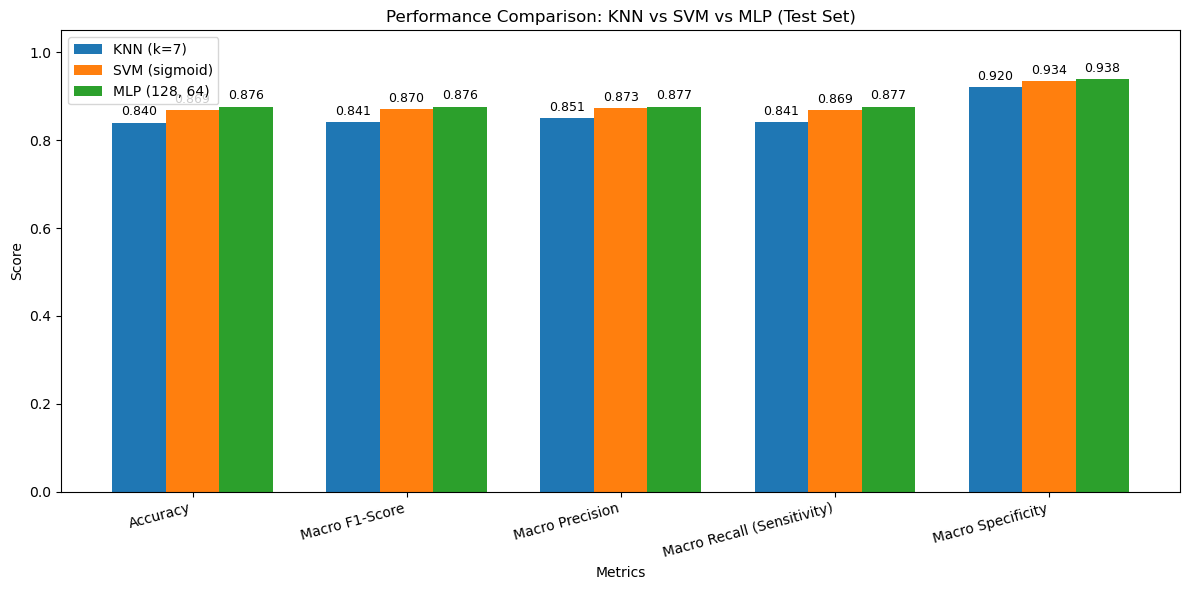

In [153]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 2. Helper function: Compute macro specificity
def macro_specificity(y_true, y_pred, n_classes=3):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    specificities = []
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - tp)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(spec)
    return np.mean(specificities)


# 3. Train and evaluate KNN 

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average='macro', zero_division=0)
rec_knn = recall_score(y_test, y_pred_knn, average='macro', zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, average='macro', zero_division=0)
spec_knn = macro_specificity(y_test, y_pred_knn)


# 4. Train and evaluate SVM 

kernels = ["linear", "rbf", "poly", "sigmoid"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for ker in kernels:
    svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=ker, random_state=42))
    ])
    acc_scores = cross_val_score(svm_clf, X, y, cv=cv, scoring="accuracy")
    f1_scores = cross_val_score(svm_clf, X, y, cv=cv, scoring="f1_macro")
    cv_rows.append({
        "Kernel": ker,
        "Acc_mean": acc_scores.mean(),
        "F1_macro_mean": f1_scores.mean(),
    })

cv_df = pd.DataFrame(cv_rows)
best_row = cv_df.sort_values("F1_macro_mean", ascending=False).iloc[0]
best_kernel = best_row["Kernel"]

# Train final SVM on TRAIN, predict on TEST 
final_svm = SVC(kernel=best_kernel, random_state=42)
final_svm.fit(X_train_scaled, y_train)
y_pred_svm = final_svm.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average="macro", zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, average="macro", zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average="macro", zero_division=0)
spec_svm = macro_specificity(y_test, y_pred_svm)

# 5. Train and evaluate MLP (select best architecture via CV)

architectures = [(32,), (64, 32), (128, 64)]
best_arch = (64, 32)
best_f1_mlp = -1

for arch in architectures:
    mlp_temp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        batch_size=32,
        max_iter=300,
        random_state=42
    )
    f1_scores = cross_val_score(mlp_temp, X_train_scaled, y_train, cv=cv, scoring='f1_macro')
    if f1_scores.mean() > best_f1_mlp:
        best_f1_mlp = f1_scores.mean()
        best_arch = arch

# Final MLP training and prediction
mlp = MLPClassifier(
    hidden_layer_sizes=best_arch,
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=300,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, average='macro', zero_division=0)
rec_mlp = recall_score(y_test, y_pred_mlp, average='macro', zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, average='macro', zero_division=0)
spec_mlp = macro_specificity(y_test, y_pred_mlp)
# 6. Create comparison DataFrame

comparison_df = pd.DataFrame({
    'Model': [f'KNN (k=7)', f'SVM ({best_kernel})', f'MLP {best_arch}'],
    'Accuracy': [acc_knn, acc_svm, acc_mlp],
    'Macro F1-Score': [f1_knn, f1_svm, f1_mlp],
    'Macro Precision': [prec_knn, prec_svm, prec_mlp],
    'Macro Recall (Sensitivity)': [rec_knn, rec_svm, rec_mlp],
    'Macro Specificity': [spec_knn, spec_svm, spec_mlp]
})

print("\n=== Model Performance Comparison (Test Set) ===")
print(comparison_df.to_string(index=False, float_format="%.4f"))


# 7. Plot comparison bar chart

metrics = ['Accuracy', 'Macro F1-Score', 'Macro Precision', 
           'Macro Recall (Sensitivity)', 'Macro Specificity']
models = comparison_df['Model'].tolist()
values = comparison_df[metrics].values

x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):
    offset = (i - 1) * width  # Center groups for 3 models
    bar = ax.bar(x + offset, values[i], width, label=model)
    # Add value labels on top of bars
    for rect in bar:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison: KNN vs SVM vs MLP (Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()